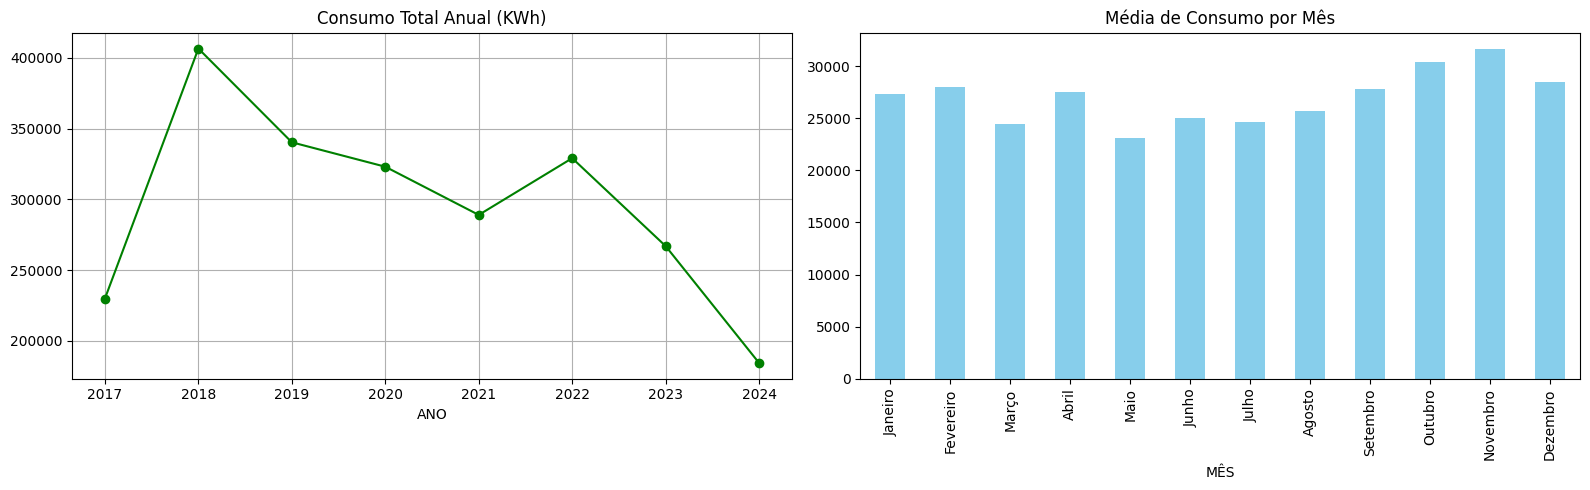

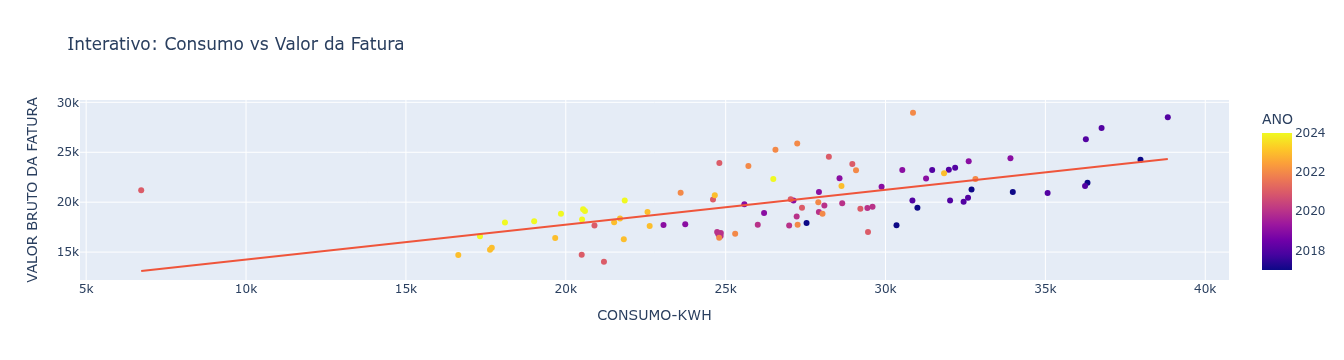

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# --- 1. CARREGAMENTO ---
url = 'https://raw.githubusercontent.com/AndersonSalata/Materiais_Alunos_EAD/main/consumo-de-energia-eletrica-no-palacio-do-jaburu-2017-2024-setembro.csv'
df = pd.read_csv(url, sep=';', encoding='latin1')

# --- 2. LIMPEZA ---
df.columns = df.columns.str.strip()
df['VALOR BRUTO DA FATURA'] = df['VALOR BRUTO DA FATURA'].astype(str).str.replace('R$', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df['VALOR BRUTO DA FATURA'] = pd.to_numeric(df['VALOR BRUTO DA FATURA'], errors='coerce')

# --- 3. CÁLCULOS E GRÁFICOS ESTÁTICOS ---
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico A: Consumo Total por Ano
df.groupby('ANO')['CONSUMO-KWH'].sum().plot(kind='line', marker='o', ax=ax[0], color='green')
ax[0].set_title('Consumo Total Anual (KWh)')
ax[0].grid(True)

# Gráfico B: Média Mensal (Sazonalidade)
meses = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']
df.groupby('MÊS')['CONSUMO-KWH'].mean().reindex(meses).plot(kind='bar', ax=ax[1], color='skyblue')
ax[1].set_title('Média de Consumo por Mês')
plt.tight_layout()
plt.show()

# --- 4. GRÁFICO INTERATIVO (CORRELAÇÃO) ---
fig_interativo = px.scatter(df, x="CONSUMO-KWH", y="VALOR BRUTO DA FATURA", color="ANO", 
                 hover_data=['MÊS'], title="Interativo: Consumo vs Valor da Fatura", trendline="ols")
fig_interativo.show()